In [1]:
"""Behavioural-metrics plotting notebook.

Generates four standard plots from the master trial table:
  1. Success rate per session per animal per day
  2. Miss rate (no poke) and error rate (wrong poke) on one plot
  3. Error angle (signed and unsigned) per animal per day
  4. Premature poke rate (correct + incorrect)

All plots respect a single filter defined in cell `filter_def`. Change the
filter, re-run, get new plots.
"""

import sys, re, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itables

itables.init_notebook_mode()

# Make the repo importable regardless of where Jupyter was launched from.
from pathlib import Path
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "src" / "data_conduit").is_dir():
    REPO_ROOT = REPO_ROOT.parent
for p in (str(REPO_ROOT), str(REPO_ROOT / "src")):
    if p not in sys.path:
        sys.path.insert(0, p)

from Q_C_Analysis_Workflow.utils import (
    build_master_trial_table,
    build_trial_table_for_directory,
    collect_session_settings_directory,
    count_premature_pokes_per_directory,
    display_table,
    parse_poke_outcome,
)

base_dir = "/home/callum/Keshavarzi-Lab-Workspace/data-conduit/datasets/firstdata/BonsaiFiles"

# Number of nosepoke ports on the rig — used to convert port indices to angles.
# 18 ports => 360 / 18 = 20 degrees per port.
N_PORTS = 18


In [2]:
#=== Load every session's settings + behavioural trials, build the master table

sessions_collected = collect_session_settings_directory(base_dir)
sessions_df = sessions_collected["sessions"]
trials_df = sessions_collected["trials"]

behavioural_trials = build_trial_table_for_directory(
    base_dir=base_dir,
    sessions_df=sessions_df,
    start="Start Trial",
    end=re.compile(r"^Poke:"),
    phases={
        "tz_available": "Target zone available",
        "tz_triggered": "Target zone triggered",
        "await_poke":   "Await poke",
    },
    segments={
        "outbound": ("start", "tz_triggered"),
        "inbound":  ("tz_triggered", "end"),
    },
    outcome_parser=parse_poke_outcome,
)

master_trials = build_master_trial_table(behavioural_trials, trials_df)

print(f"sessions: {len(sessions_df)}, behavioural trials: {len(behavioural_trials)}, master trials: {len(master_trials)}")



                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
sessions: 290, behavioural trials: 7804, master trials: 7804


In [3]:
#=== Derived columns on master_trials
#
# - day_num            : numeric day extracted from the directory name
# - signed_error_angle : (chosen - correct) port offset, wrapped to [-9, 9],
#                        converted to degrees. Positive = right of correct,
#                        negative = left.
# - absolute_error_angle : |signed_error_angle|. Misses (chosen=-1) -> NaN.
# - lights_on          : True if ANY visual cue (landmark / proximal landmark
#                        / grating / firefly) is being drawn for that trial.

master_trials["day_num"] = master_trials["day"].str.extract(r"(\d+)").astype(int)

half_n = N_PORTS // 2
signed_offset = (
    (master_trials["chosen_port"] - master_trials["correct_port"] + half_n) % N_PORTS
) - half_n
master_trials["signed_error_angle"] = np.where(
    master_trials["chosen_port"] >= 0,
    signed_offset * (360.0 / N_PORTS),
    np.nan,
)
master_trials["absolute_error_angle"] = master_trials["signed_error_angle"].abs()

visual_cols = [
    "bonsai_landmark.draw",
    "bonsai_landmarkProximal.draw",
    "bonsai_grating.draw",
    "bonsai_firefly.draw",
]
master_trials["lights_on"] = master_trials[visual_cols].any(axis=1)

print("Lights distribution across trials:")
print(master_trials["lights_on"].value_counts().to_string())


Lights distribution across trials:
lights_on
False    7804


In [4]:
#=== Premature poke counts per session
#
# A premature poke = a Poke event between two consecutive Start Trial events
# (i.e. fired while no trial is open). This experiment's ExperimentEvents log
# only records "Poke:" entries when the cue tone allows pokes, so this count
# is typically zero — non-zero values would indicate the workflow event
# vocabulary changed, or you point this at raw nosepoke streams instead.

premature_per_session = count_premature_pokes_per_directory(
    base_dir=base_dir,
    sessions_df=sessions_df,
    start_marker="Start Trial",
    poke_marker=re.compile(r"^Poke:"),
    poke_extractor=parse_poke_outcome,
)
premature_per_session["day_num"] = premature_per_session["day"].str.extract(r"(\d+)").astype(int)

# Carry the lights_on setting from the matching session into the premature table
# (use the modal value across that session's trials).
session_lights = (
    master_trials.groupby("USID")["lights_on"]
    .agg(lambda s: bool(s.mode().iloc[0]) if not s.empty else False)
    .rename("lights_on")
)
premature_per_session = premature_per_session.merge(session_lights.reset_index(), on="USID", how="left")

display_table(premature_per_session)


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [5]:
#=== Show only the columns relevant to behavioural plots
#
# master_trials has 150+ columns; most are Bonsai parameters you don't need
# for these plots. Build a shortlist and use it whenever you display the
# table.

relevant_columns = [
    "UTID", "USID", "mouse", "day", "day_num", "session", "trial_index",
    "outcome", "success", "chosen_port", "correct_port",
    "signed_error_angle", "absolute_error_angle",
    "outbound_duration", "inbound_duration",
    "lights_on",
]

display_table(master_trials[relevant_columns])


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [6]:
#=== Filter — change this single boolean mask and re-run the plot cells
#
# Each parenthesised expression is a boolean Series. Combine with & (and) / |
# (or). Examples below — uncomment / adjust to taste:
#
#   filter_mask = (master_trials["lights_on"] == False)                                  # lights-off only
#   filter_mask &= master_trials["mouse"].isin(["FL_M01569519", "MR_M01569515"])         # subset of mice
#   filter_mask &= master_trials["day_num"].between(3, 14)                               # day range
#   filter_mask &= master_trials["outcome"].isin(["success", "fail"])                    # exclude misses
#
# The plot cells below derive their slices from `filtered_master`.

filter_mask = (
    master_trials["lights_on"] == False
)

filtered_master = master_trials[filter_mask].copy()

# Carry the same filter through the premature-poke session table so the two
# stay consistent (premature plots are session-level, not trial-level, so we
# match by USID).
filtered_premature = premature_per_session[
    premature_per_session["USID"].isin(filtered_master["USID"].unique())
].copy()

print(f"trials kept: {len(filtered_master):,} / {len(master_trials):,}")
print(f"sessions kept: {filtered_master['USID'].nunique()} / {master_trials['USID'].nunique()}")
print(f"mice in filter: {sorted(filtered_master['mouse'].unique())}")


trials kept: 7,804 / 7,804
sessions kept: 290 / 290
mice in filter: ['FLR_M01569521', 'FL_M01569519', 'FbR_M01569522', 'MR_M01569515', 'MbL_M01569517']


In [7]:
#=== Tiny plotting helper — used by every plot cell
#
# Takes a long-form DataFrame with columns [mouse, day_num, value] (one row
# per session). Plots:
#   - one transparent point per session, coloured by mouse
#   - one bold marker per (mouse, day_num), the mean of that mouse's sessions
#   - one black dashed line of best fit across ALL sessions in the input
#
# `title` and `ylabel` flow into the axes labels.

def plot_per_session_with_lobf(
    ax, data, *, value_col, title, ylabel, marker_size=20, mean_size=120,
):
    mice = sorted(data["mouse"].unique())
    cmap = plt.get_cmap("tab10")
    colours = {m: cmap(i % 10) for i, m in enumerate(mice)}

    for m in mice:
        sub = data[data["mouse"] == m]
        ax.scatter(sub["day_num"], sub[value_col], color=colours[m], alpha=0.25,
                   s=marker_size, edgecolor="none", label=None)
        per_day = sub.groupby("day_num", as_index=False)[value_col].mean()
        ax.scatter(per_day["day_num"], per_day[value_col], color=colours[m],
                   s=mean_size, edgecolor="black", linewidth=0.8, label=m, zorder=3)

    xs_all = pd.to_numeric(data["day_num"], errors="coerce").to_numpy()
    ys_all = pd.to_numeric(data[value_col], errors="coerce").to_numpy()
    finite = np.isfinite(xs_all) & np.isfinite(ys_all)
    if finite.sum() >= 2:
        slope, intercept = np.polyfit(xs_all[finite], ys_all[finite], 1)
        line_xs = np.linspace(xs_all[finite].min(), xs_all[finite].max(), 50)
        ax.plot(line_xs, slope * line_xs + intercept, color="black", linestyle="--",
                linewidth=2, label=f"LoBF (slope={slope:+.3f})", zorder=4)

    ax.set_title(title)
    ax.set_xlabel("Day")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="best")


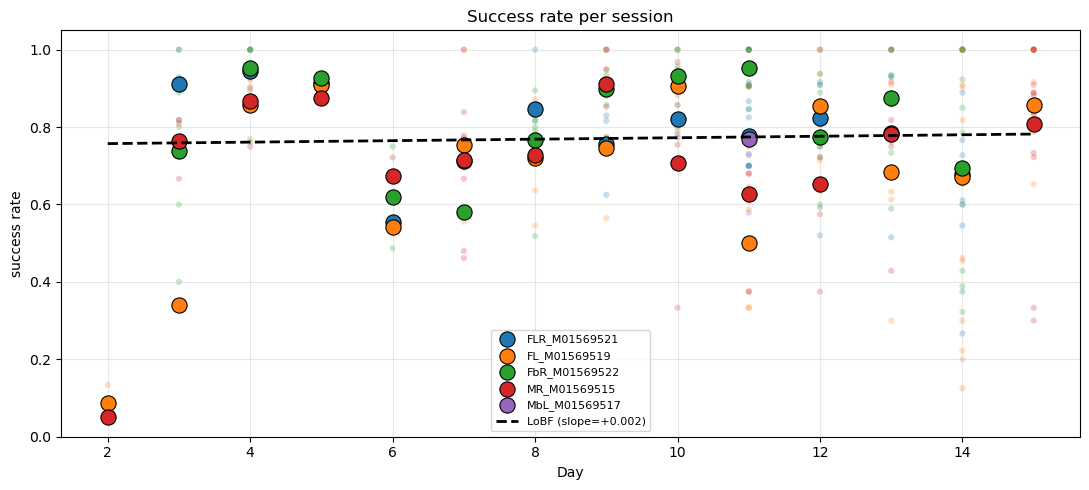

In [8]:
#=== Plot 1 — Success rate per session per animal per day

success_per_session = (
    filtered_master
    .groupby(["mouse", "day_num", "USID"], as_index=False)
    .agg(success_rate=("success", "mean"))
)

fig, ax = plt.subplots(figsize=(11, 5))
plot_per_session_with_lobf(
    ax, success_per_session,
    value_col="success_rate",
    title="Success rate per session",
    ylabel="success rate",
)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


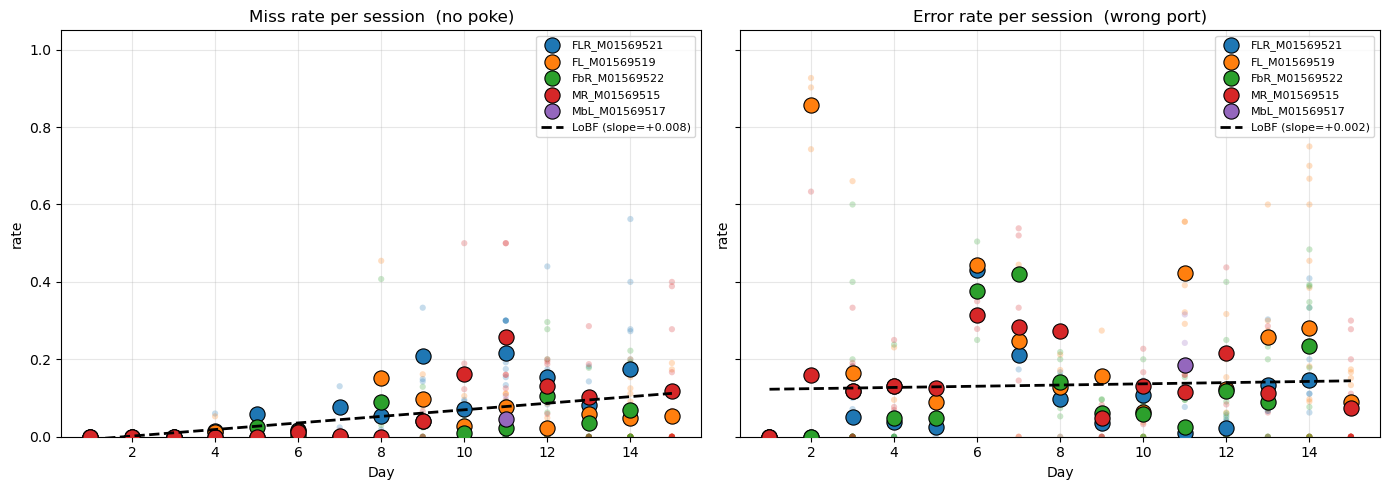

In [9]:
#=== Plot 2 — Miss rate and error rate on the same axes
#
# miss  = no poke (chosen_port == -1, outcome == "miss")
# error = poked the wrong port (outcome == "fail")
# success is excluded — that's plot 1's topic.

rates_per_session = (
    filtered_master
    .groupby(["mouse", "day_num", "USID"])
    .agg(
        miss_rate=("outcome", lambda s: (s == "miss").mean()),
        error_rate=("outcome", lambda s: (s == "fail").mean()),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_per_session_with_lobf(
    axes[0], rates_per_session,
    value_col="miss_rate",
    title="Miss rate per session  (no poke)",
    ylabel="rate",
)
plot_per_session_with_lobf(
    axes[1], rates_per_session,
    value_col="error_rate",
    title="Error rate per session  (wrong port)",
    ylabel="rate",
)
for ax in axes:
    ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


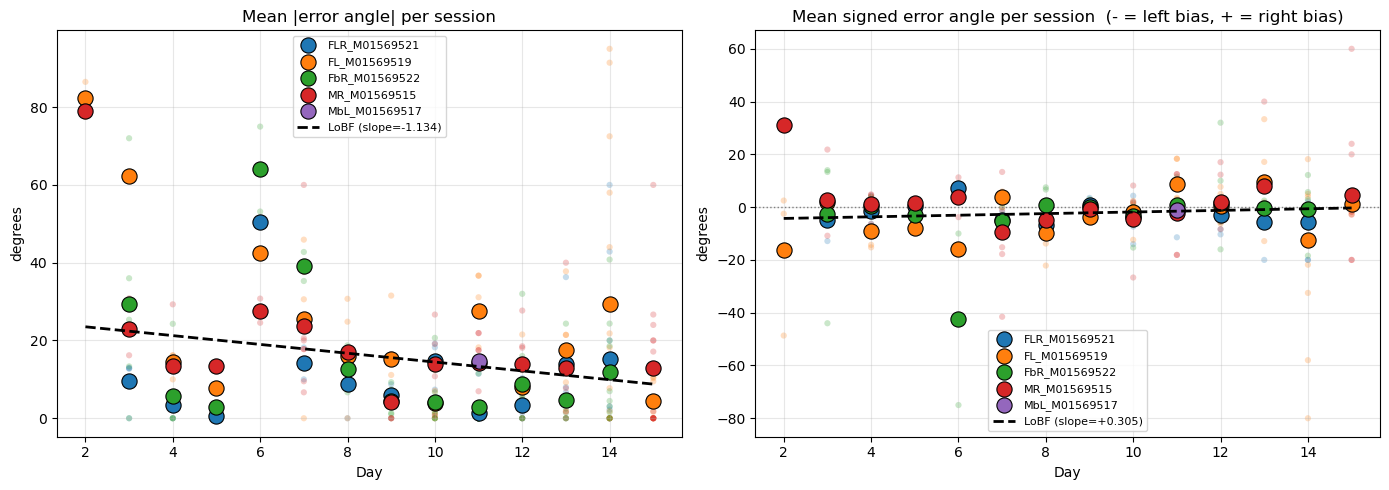

In [10]:
#=== Plot 3 — Error angle per animal per day, with LoBF
#
# Left:  unsigned magnitude — how far off was the poke?
# Right: signed (positive = right of correct, negative = left). A persistent
#        non-zero mean indicates a left/right bias. Misses are excluded.

errored_only = filtered_master[filtered_master["chosen_port"] >= 0]
angle_per_session = (
    errored_only
    .groupby(["mouse", "day_num", "USID"], as_index=False)
    .agg(
        absolute_error_angle=("absolute_error_angle", "mean"),
        signed_error_angle=("signed_error_angle", "mean"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_per_session_with_lobf(
    axes[0], angle_per_session,
    value_col="absolute_error_angle",
    title="Mean |error angle| per session",
    ylabel="degrees",
)
plot_per_session_with_lobf(
    axes[1], angle_per_session,
    value_col="signed_error_angle",
    title="Mean signed error angle per session  (- = left bias, + = right bias)",
    ylabel="degrees",
)
axes[1].axhline(0, color="grey", linewidth=1, linestyle=":")
plt.tight_layout()
plt.show()


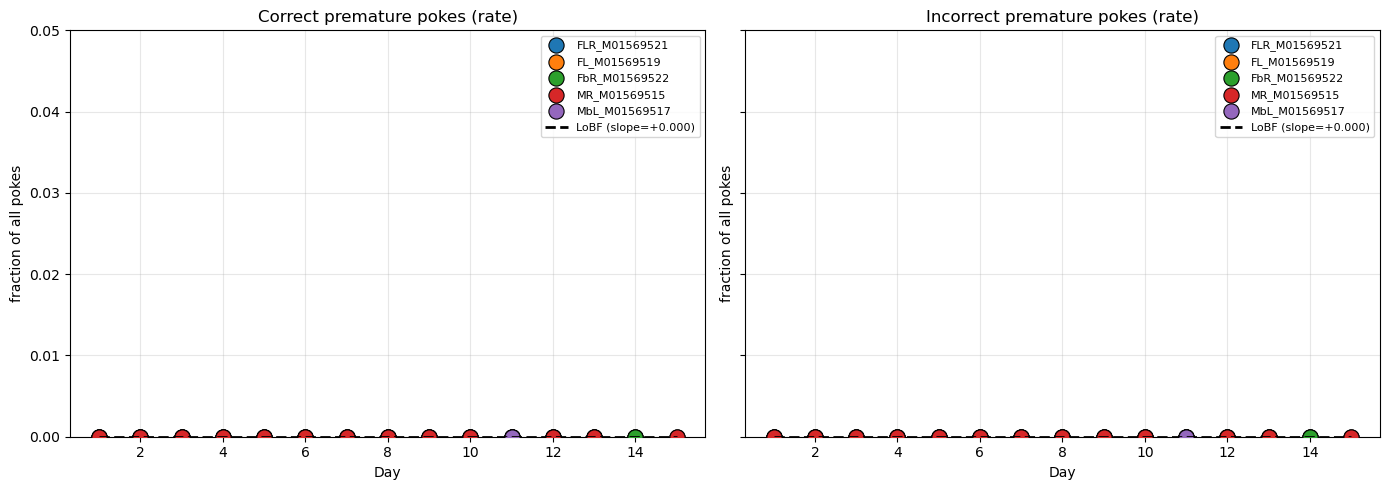

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [11]:
#=== Plot 4 — Premature poke rate per session
#
# correct premature   : poked the next trial's correct port early
# incorrect premature : poked any other port (or no port) early
#
# NOTE: in this dataset the ExperimentEvents "Poke:" line only fires while
# the cue tone allows pokes, so true premature pokes show up as zero. To
# detect raw between-trial nosepokes you'd need to wire the HARP nosepoke
# streams in alongside ExperimentEvents and call
# count_premature_pokes_per_directory with a marker pointing at those.

if filtered_premature["n_pokes"].sum() > 0:
    rate_data = filtered_premature.assign(
        correct_rate=lambda d: d["n_premature_correct"] / d["n_pokes"],
        incorrect_rate=lambda d: d["n_premature_incorrect"] / d["n_pokes"],
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    plot_per_session_with_lobf(
        axes[0], rate_data, value_col="correct_rate",
        title="Correct premature pokes (rate)", ylabel="fraction of all pokes",
    )
    plot_per_session_with_lobf(
        axes[1], rate_data, value_col="incorrect_rate",
        title="Incorrect premature pokes (rate)", ylabel="fraction of all pokes",
    )
    for ax in axes:
        ax.set_ylim(0, max(0.05, rate_data[["correct_rate", "incorrect_rate"]].max().max() * 1.1))
    plt.tight_layout()
    plt.show()
else:
    print("No pokes in filter — nothing to plot.")

display_table(filtered_premature)


In [12]:
#=== TRIAL-POOLED VIEW (the correct one)
#
# The plots above aggregate to one point per session, then average those.
# That treats a 5-trial session as worth as much as a 200-trial session,
# which inflates the noise from short or aborted sessions and gives every
# session's parameter set the same vote — even when that "session" only
# contributed a handful of trials.
#
# The cells below fix that:
#   1. Filter the trial-level master_trials with whatever criteria you want
#      (parameters, outcomes, mice, days, ...).
#   2. Pool ALL matching trials per (mouse, day_num).
#   3. Plot one marker per (mouse, day_num), size proportional to sqrt(n_trials),
#      so days/mice with more data are visually heavier.
#   4. Compute LoBF on individual trials (every trial is a sample), so
#      it's genuinely "across all included trials" — no session weighting.
#
# Filtering pattern is the same as filter_def_001 above. Examples below
# show parameter-based filters; uncomment the ones you want and re-run.

trial_filter_mask = (
    master_trials["lights_on"] == False                                    # lights off only
    # & (master_trials["bonsai_landmark.draw"] == True)                    # explicit setting on
    # & (master_trials["bonsai_targetZone.zoneRange_0"] == 0)              # specific zone parameter
    # & master_trials["mouse"].isin(["FL_M01569519", "MR_M01569515"])      # subset of mice
    # & master_trials["day_num"].between(3, 14)                            # day range
    # & master_trials["outcome"].isin(["success", "fail"])                 # exclude misses
)

trials_pooled_input = master_trials[trial_filter_mask].copy()
trials_pooled_input["success_indicator"] = (trials_pooled_input["outcome"] == "success").astype(float)
trials_pooled_input["miss_indicator"]    = (trials_pooled_input["outcome"] == "miss").astype(float)
trials_pooled_input["error_indicator"]   = (trials_pooled_input["outcome"] == "fail").astype(float)

print(f"trials in pooled view : {len(trials_pooled_input):,}")
print(f"sessions contributing : {trials_pooled_input['USID'].nunique()}")
print(f"mice                  : {sorted(trials_pooled_input['mouse'].unique())}")


trials in pooled view : 7,804
sessions contributing : 290
mice                  : ['FLR_M01569521', 'FL_M01569519', 'FbR_M01569522', 'MR_M01569515', 'MbL_M01569517']


In [13]:
#=== Pooled-plot helper
#
# One marker per (mouse, day_num) — colour = mouse, size proportional to
# sqrt(n_trials) so days with more data look heavier. LoBF runs through
# the trial-level scatter (every trial a sample), giving a properly
# trial-weighted slope.
#
# show_trial_dots=True overlays the raw per-trial values; useful for
# continuous metrics (error angle), uninformative for 0/1 indicators.

def plot_trial_pooled(
    ax, data, *, value_col, title, ylabel,
    show_trial_dots=False,
    marker_size_min=40,
    marker_size_max=300,
):
    mice = sorted(data["mouse"].unique())
    cmap = plt.get_cmap("tab10")
    colours = {m: cmap(i % 10) for i, m in enumerate(mice)}

    work = data.assign(
        _value=pd.to_numeric(data[value_col], errors="coerce"),
        _day=pd.to_numeric(data["day_num"], errors="coerce"),
    ).dropna(subset=["_value", "_day"])

    if show_trial_dots:
        for m in mice:
            sub = work[work["mouse"] == m]
            ax.scatter(sub["_day"], sub["_value"], color=colours[m],
                       alpha=0.05, s=6, label=None, zorder=1, edgecolor="none")

    pooled = (
        work.groupby(["mouse", "_day"], as_index=False)
        .agg(mean_value=("_value", "mean"), n_trials=("_value", "size"))
    )

    if not pooled.empty:
        max_n = max(pooled["n_trials"].max(), 1)
        pooled["_size"] = (
            (pooled["n_trials"] / max_n) ** 0.5 * marker_size_max
        ).clip(lower=marker_size_min, upper=marker_size_max)

        for m in mice:
            sub = pooled[pooled["mouse"] == m]
            if sub.empty:
                continue
            ax.scatter(sub["_day"], sub["mean_value"], color=colours[m],
                       s=sub["_size"], edgecolor="black", linewidth=0.8,
                       label=m, zorder=3)

    xs = work["_day"].to_numpy()
    ys = work["_value"].to_numpy()
    if len(xs) >= 2:
        slope, intercept = np.polyfit(xs, ys, 1)
        line_xs = np.linspace(xs.min(), xs.max(), 50)
        ax.plot(line_xs, slope * line_xs + intercept, color="black",
                linestyle="--", linewidth=2,
                label=f"LoBF on {len(xs):,} trials (slope={slope:+.4f})",
                zorder=4)

    ax.set_title(title)
    ax.set_xlabel("Day")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="best")


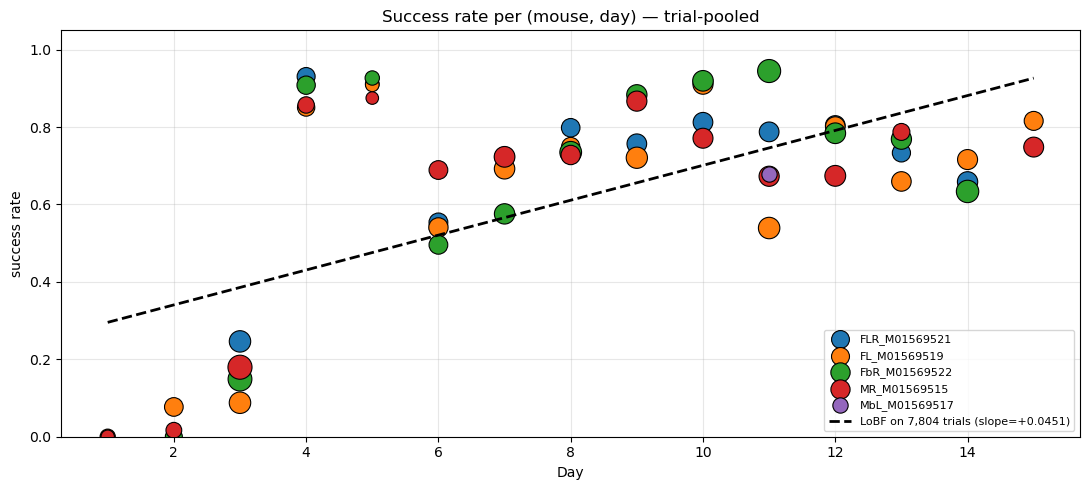

In [14]:
#=== Pooled plot 1 — Success rate (trial-pooled)

fig, ax = plt.subplots(figsize=(11, 5))
plot_trial_pooled(
    ax, trials_pooled_input,
    value_col="success_indicator",
    title="Success rate per (mouse, day) — trial-pooled",
    ylabel="success rate",
)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


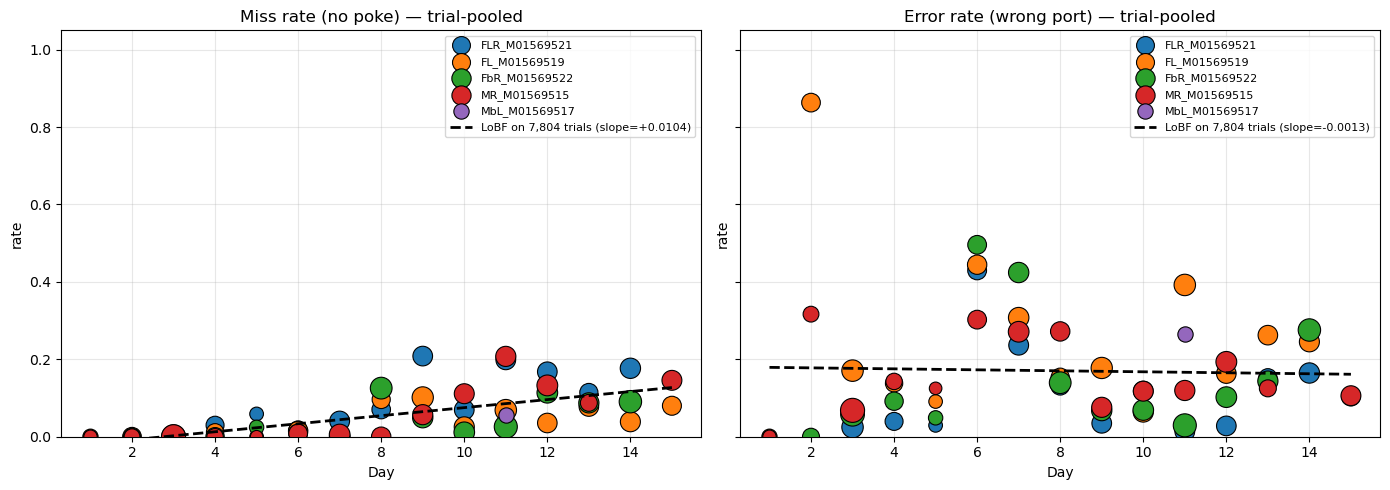

In [15]:
#=== Pooled plot 2 — Miss rate / error rate (trial-pooled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_trial_pooled(
    axes[0], trials_pooled_input,
    value_col="miss_indicator",
    title="Miss rate (no poke) — trial-pooled",
    ylabel="rate",
)
plot_trial_pooled(
    axes[1], trials_pooled_input,
    value_col="error_indicator",
    title="Error rate (wrong port) — trial-pooled",
    ylabel="rate",
)
for ax in axes:
    ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


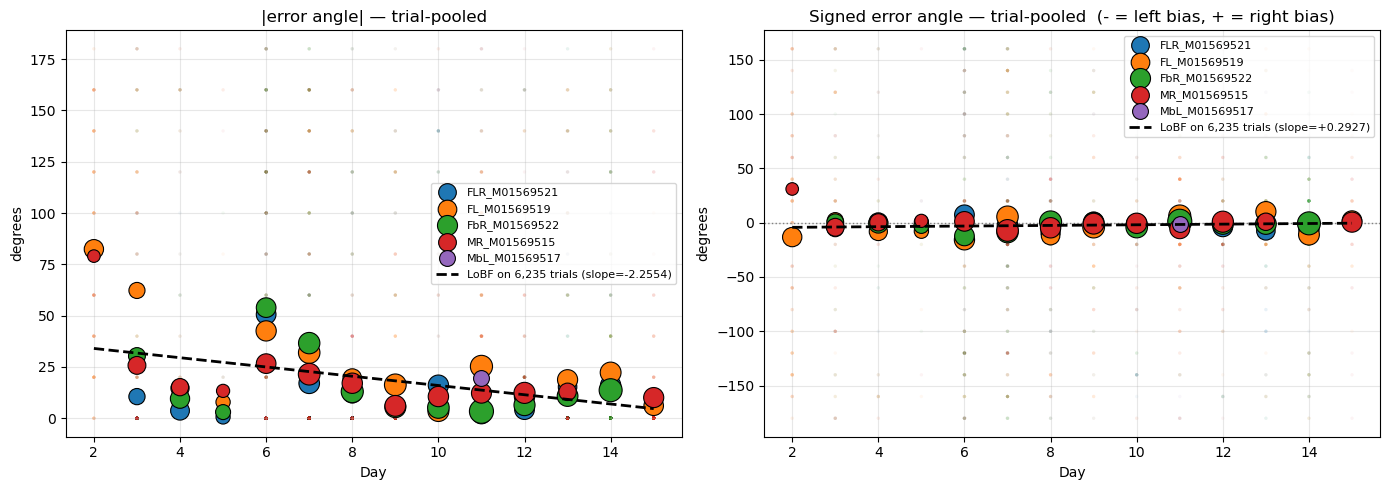

In [16]:
#=== Pooled plot 3 — Error angle (trial-pooled)
#
# Continuous values, so we can usefully show every trial as an alpha dot
# (misses excluded; chosen_port == -1 has no defined angle).

errored = trials_pooled_input[trials_pooled_input["chosen_port"] >= 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_trial_pooled(
    axes[0], errored,
    value_col="absolute_error_angle",
    title="|error angle| — trial-pooled",
    ylabel="degrees",
    show_trial_dots=True,
)
plot_trial_pooled(
    axes[1], errored,
    value_col="signed_error_angle",
    title="Signed error angle — trial-pooled  (- = left bias, + = right bias)",
    ylabel="degrees",
    show_trial_dots=True,
)
axes[1].axhline(0, color="grey", linewidth=1, linestyle=":")
plt.tight_layout()
plt.show()
